/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[Warning] Fused window process have not been installed. Please refer to get_started.md for installation.
To use FusedLAMB or FusedAdam, please install apex.
=> merge config from /workspace/our_method/modules/swin_transformer/configs/simmim/pt_bt_ustc2016.yaml
[warning] Apex amp has been deprecated, please use pytorch amp instead!
RANK and WORLD_SIZE in environ: 0/1
[2025-12-16 10:54:02 swin_base_patch4_window7_224](3070377457.py 276): INFO {}


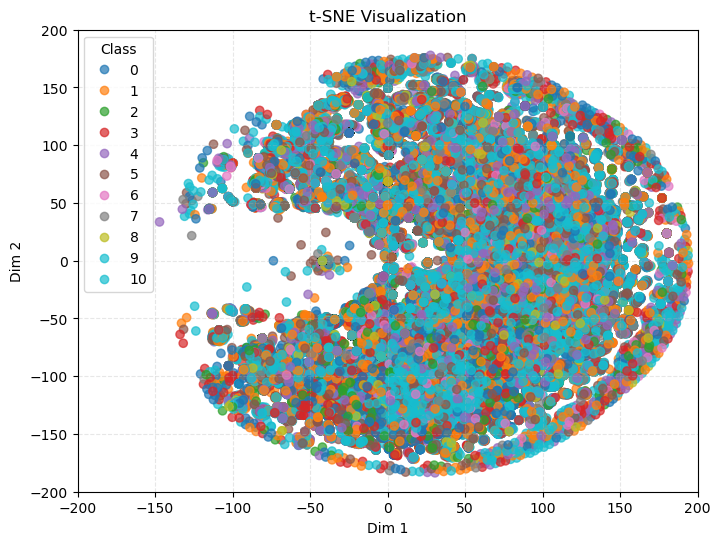

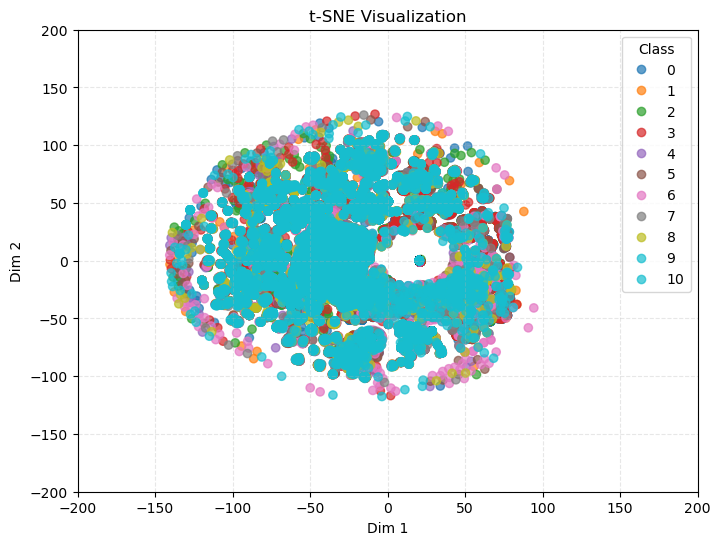

クラス：[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
カウント[4742, 4742, 4742, 4742, 4742, 4742, 4742, 4742, 4742, 4742, 4742]


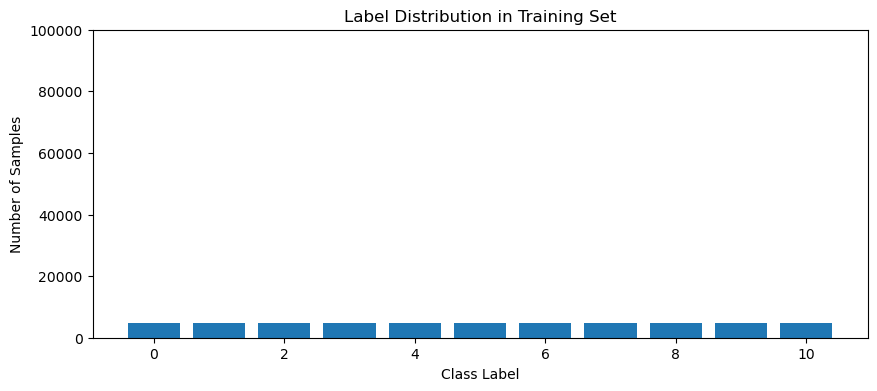

/opt/conda/envs/anaconda3-cuda/lib/python3.8/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905971873/work/aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[2025-12-16 11:33:42 swin_base_patch4_window7_224](3070377457.py 139): INFO Start training
[2025-12-16 11:35:10 swin_base_patch4_window7_224](utils.py 277): INFO pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_0.pth saving......
[2025-12-16 11:35:11 swin_base_patch4_window7_224](utils.py 280): INFO pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_0.pth saved !!!
[2025-12-16 11:35:11 swin_base_patch4_window7_224](3070377457.py 152): INFO Loss 124.0132
[2025-12-16 11:36:38 swin_base_patch4_window7_224](utils.py 277): INFO pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_1.pth saving......
[2025-12-16 11:36:38 swin_base_patch4_window7_224](utils.py 280): INFO pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_1.pth saved !!!
[2025-12-16 11:36:38 swin_base_patch4_window7_224](3070377457.py 152): INFO Loss 85.6158
[2025-12-16 11:38:06 swin_base_patch4_window7_224](utils.py 277): INFO pt_output/swin_base_patch4_window7_224/default/ckpt_epoch_2.pth saving...

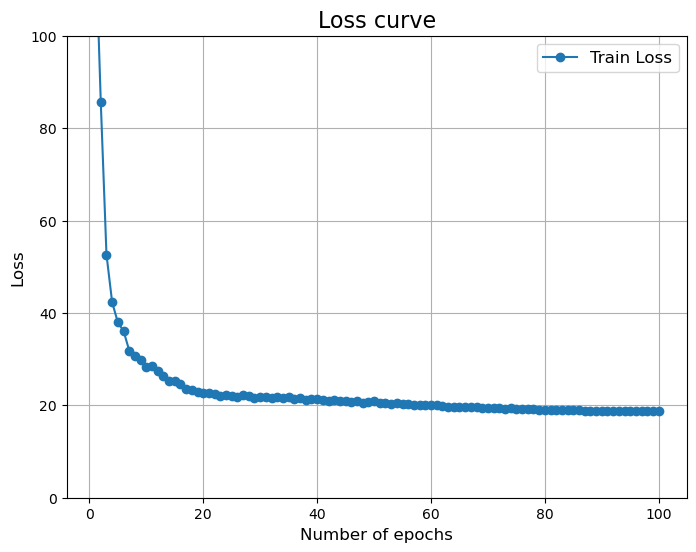

In [1]:
import os
import time
import json
import random
import argparse
import datetime
import numpy as np
import ast

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.distributed as dist
from torch.utils.data import Dataset
from torch import optim
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#from sklearn.metrics import precision_recall_fscore_support, accuracy_score

from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.utils import accuracy, AverageMeter

from PIL import Image

from modules.swin_transformer.config import get_config
from modules.swin_transformer.models import build_model
from data import build_loader
from modules.swin_transformer.lr_scheduler import build_scheduler
from modules.swin_transformer.optimizer import build_optimizer
from modules.swin_transformer.logger import create_logger
from modules.swin_transformer.utils import load_checkpoint_bt, load_pretrained, save_checkpoint_simgbt, NativeScalerWithGradNormCount, auto_resume_helper, \
    reduce_tensor

from data.create_dataset.raw_dataset import TrafficDataset
from data.create_dataset.data_dist import data_distribution

from modules.gnn.models.gat import GAT as gat
from modules.gnn.models.fast_gcn import FastGCN as fast
from modules.gnn.models.comb_gnn import CombinedGNN
from modules.comb_module import CombinedModule
from modules.gnn.pretrain.gbt_sim_trainer import Trainer
#from modules.swin_transformer.simmim_pt import SimmimTrainer

# pytorch major version (1.x or 2.x)
PYTORCH_MAJOR_VERSION = int(torch.__version__.split('.')[0])

# 参照元のコードはコマンドラインで引数を指定
# jupyter lab上で機能するように、引数
def parse_option():
    class Args:
        cfg = "/workspace/our_method/modules/swin_transformer/configs/simmim/pt_bt_ustc2016.yaml"
        opts  = None
        # ustcに変更必要
        data_path = ["/workspace/dataset/ustc-tfc2016/parsed_raw", "/workspace/dataset/ustc-tfc2016/graph"]
        zip = False
        cache_mode = 'part'
        pretrained = True
        resume = None
        accumulation_steps = 4
        use_checkpoint =  False
        disable_amp = False
        amp_opt_level = '01'
        output = 'pt_output'
        tag = None
        eval = False
        throughput = False
        os.environ['RANK'] = '0'
        os.environ['LOCAL_RANK'] = '0'  
        os.environ['WORLD_SIZE'] = '1'
        os.environ['MASTER_ADDR'] = 'localhost'
        os.environ['MASTER_PORT'] = '29500'
        fused_window_process = False
        fused_layernorm = False
        optim = 'adamw'

    # 引数をインスタンス化
    args = Args()

    # configファイルの読み込みや設定を行う関数を呼び出し
    config = get_config(args)

    return args, config

def main(config, device):
    combined_train, combined_dataloader_train = build_loader(config, simmim=True, is_pretrain=True)

    # データ（ラベル）分布の表示
    data_distribution(combined_train)
    
    # gnnのパラメータ
    graph_dataset, raw_dataset = combined_train[0]
    features = graph_dataset["graph"][0].ndata["feat"]
    in_dim = features.shape[1]
    
    #モデルの構築
    swin_model = build_model(config, is_pretrain=True)
    gat_model = gat(config, in_dim, device)
    fast_model = fast(config, in_dim, device)    
    gnn_model = CombinedGNN(config, gat_model, fast_model, device)
    params = list(gnn_model.parameters()) + list(swin_model.parameters())
    optimizer = optim.AdamW(params, lr=config.TRAIN.BASE_LR, weight_decay=config.TRAIN.WEIGHT_DECAY)
    
    # lr scheduler
    if config.TRAIN.ACCUMULATION_STEPS > 1:
        lr_scheduler = build_scheduler(config, optimizer, len(combined_dataloader_train) // config.TRAIN.ACCUMULATION_STEPS)
    else:
        lr_scheduler = build_scheduler(config, optimizer, len(combined_dataloader_train))

    scaler = NativeScalerWithGradNormCount()

    if config.AUG.MIXUP > 0.:
        # smoothing is handled with mixup label transform
        criterion = SoftTargetCrossEntropy()
    elif config.MODEL.LABEL_SMOOTHING > 0.:
        criterion = LabelSmoothingCrossEntropy(smoothing=config.MODEL.LABEL_SMOOTHING)
    else:
        criterion = torch.nn.CrossEntropyLoss()

    max_accuracy = 0.0

    if config.TRAIN.AUTO_RESUME:
        resume_file = auto_resume_helper(config.OUTPUT)
        if resume_file:
            if config.MODEL.RESUME:
                logger.warning(f"auto-resume changing resume file from {config.MODEL.RESUME} to {resume_file}")
            config.defrost()
            config.MODEL.RESUME = resume_file
            config.freeze()
            logger.info(f'auto resuming from {resume_file}')
        else:
            logger.info(f'no checkpoint found in {config.OUTPUT}, ignoring auto resume')

    # pt-trainer
    trainer = Trainer(config, gnn_model, swin_model, params, optimizer, lr_scheduler, scaler, device)
    
    logger.info("Start training")
    start_time = time.time()
    loss_meter = AverageMeter()
    loss_history = []
    
    for epoch in range(config.TRAIN.START_EPOCH, config.TRAIN.EPOCHS):
        loss = trainer.train(combined_dataloader_train, epoch)
        loss_history.append(loss)
        
        # セーブ頻度に応じてパラメータを保存
        if dist.get_rank() == 0 and (epoch % config.SAVE_FREQ == 0 or epoch == (config.TRAIN.EPOCHS - 1)):
            save_checkpoint_simgbt(config, gnn_model, swin_model, optimizer, lr_scheduler, scaler, logger, epoch)
            
        logger.info(f'Loss {loss:.4f}')

    total_time = time.time() - start_time
    total_time_str = str(datetime.timedelta(seconds=int(total_time)))
    logger.info(f'Training time {total_time_str}')

    draw_loss_curb(loss_history)


# 学習時間を計測
@torch.no_grad()
def throughput(data_loader, model, logger):
    model.eval()

    for idx, (images, _) in enumerate(data_loader):
        images = images.cuda(non_blocking=True)
        batch_size = images.shape[0]
        for i in range(50):
            model(images)
        torch.cuda.synchronize()
        logger.info(f"throughput averaged with 30 times")
        tic1 = time.time()
        for i in range(30):
            model(images)
        torch.cuda.synchronize()
        tic2 = time.time()
        logger.info(f"batch_size {batch_size} throughput {30 * batch_size / (tic2 - tic1)}")
        return

def draw_train_curb(train_acc_avg, test_acc_avg=None):
    epochs = list(range(1, len(train_acc_avg) + 1))
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_acc_avg, marker='o', label='Train Accuracy')
    if test_loss_avg is not None:
        plt.plot(epochs, test_acc_avg, marker='s', linestyle='--', label='Validation accuracy')
    
    plt.grid()
    plt.title('Learning curve', fontsize=16)
    plt.xlabel('Number of epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.ylim([0, 100])
    plt.show()

def draw_loss_curb(train_loss_avg):
    epochs = list(range(1, len(train_loss_avg) + 1))
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_loss_avg, marker='o', label='Train Loss')
    plt.grid()
    plt.title('Loss curve', fontsize=16)
    plt.xlabel('Number of epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.ylim([0, 100])
    plt.show()

def plot_confusion_matrix(all_pred, all_target, class_names, normalize='true'):
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_target).numpy()
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    args, config = parse_option()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if config.AMP_OPT_LEVEL:
        print("[warning] Apex amp has been deprecated, please use pytorch amp instead!")

    if 'MASTER_PORT' not in os.environ:
        os.environ['MASTER_PORT'] = str(config.DISTRIBUTED.PORT)
    
    if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
        rank = int(os.environ["RANK"])
        world_size = int(os.environ['WORLD_SIZE'])
        print(f"RANK and WORLD_SIZE in environ: {rank}/{world_size}")
    else:
        rank = -1
        world_size = -1
    torch.cuda.set_device(config.LOCAL_RANK)

    if config.DISTRIBUTED.ENABLE and not torch.distributed.is_initialized():
        torch.distributed.init_process_group(
            backend=config.DISTRIBUTED.BACKEND,
            init_method=config.DISTRIBUTED.INIT_METHOD,
            world_size=world_size,
            rank=rank
        )
        torch.distributed.barrier()

    seed = config.SEED + dist.get_rank()
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    cudnn.benchmark = True

    # linear scale the learning rate according to total batch size, may not be optimal
    #linear_scaled_lr = config.TRAIN.BASE_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    linear_scaled_warmup_lr = config.TRAIN.WARMUP_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    linear_scaled_min_lr = config.TRAIN.MIN_LR * config.DATA.BATCH_SIZE * dist.get_world_size() / 512.0
    # gradient accumulation also need to scale the learning rate
    if config.TRAIN.ACCUMULATION_STEPS > 1:
        #linear_scaled_lr = linear_scaled_lr * config.TRAIN.ACCUMULATION_STEPS
        linear_scaled_warmup_lr = linear_scaled_warmup_lr * config.TRAIN.ACCUMULATION_STEPS
        linear_scaled_min_lr = linear_scaled_min_lr * config.TRAIN.ACCUMULATION_STEPS
    config.defrost()
    
    #config.TRAIN.BASE_LR = linear_scaled_lr
    config.TRAIN.WARMUP_LR = linear_scaled_warmup_lr
    config.TRAIN.MIN_LR = linear_scaled_min_lr
# pytorch major version (1.x or 2.x)

    os.makedirs(config.OUTPUT, exist_ok=True)
    logger = create_logger(output_dir=config.OUTPUT, dist_rank=dist.get_rank(), name=f"{config.MODEL.NAME}")

    # print config
    #logger.info(config.dump())
    logger.info(json.dumps(vars(args)))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    main(config, device)